In [449]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from skforecast.recursive import ForecasterRecursive
from sklearn.ensemble import RandomForestRegressor
from skforecast.model_selection import TimeSeriesFold, grid_search_forecaster, backtesting_forecaster
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skforecast.utils import save_forecaster, load_forecaster

In [94]:
print("Sales prediction")

Sales prediction


In [3]:
#data = { 'Fruits': ['Apple', 'Orange', 'Pears', 'Apple', 'Apple', 'Guava', 'Banana', 'Pears', 'Pineapple', 'Apple', 'Papaya'],
#        'Bags': [5, 6, 3, 7, 15, 0, 10, 8, 0, 18, 13],
#        'Colors': ['red', 'orange', 'yellow', 'red', 'red', 'green', 'red', 'pink', 'yellow', 'red', 'yellow'],
#        'Sector': ['A', 'A', 'B', 'A', 'C', 'D', 'A', 'B', 'E', 'C', 'E'] }
#df = pd.DataFrame(data)

#print(df)

In [104]:
# CSV file TransactionDate values in 1/14/2013 format

fpath = 'C:\\Users\\Hatim.Hakeel\\Downloads\\WideWorldImporters_ToysAndMachines.csv'
df = pd.read_csv(fpath, parse_dates=['TransactionDate'], date_format='%m/%d/%Y')

In [105]:
print(df)

       CustomerTransactionID  CustomerID  TransactionTypeID  InvoiceID  \
0                          7           1                  1          3   
1                         11           1                  1          4   
2                         31           1                  1          9   
3                         34           1                  1         10   
4                         66           1                  1         21   
...                      ...         ...                ...        ...   
22311                 336159           1                  1      70489   
22312                 336189           1                  1      70497   
22313                 336199           1                  1      70499   
22314                 336208           1                  1      70501   
22315                 336246           1                  1      70509   

       PaymentMethodID TransactionDate  AmountExcludingTax  TaxAmount  \
0                  NaN      2013-01-01

In [106]:
print(df.dtypes)

CustomerTransactionID             int64
CustomerID                        int64
TransactionTypeID                 int64
InvoiceID                         int64
PaymentMethodID                 float64
TransactionDate          datetime64[ns]
AmountExcludingTax              float64
TaxAmount                       float64
TransactionAmount               float64
OutstandingBalance              float64
FinalizationDate                 object
IsFinalized                       int64
LastEditedBy                      int64
LastEditedWhen                   object
dtype: object


In [107]:
df[['TrxTotal']] = df.groupby('TransactionDate').agg({'TransactionAmount': 'cumsum'})
df = df.drop_duplicates(subset=['TransactionDate'], keep='last', ignore_index=True)

print(df)

      CustomerTransactionID  CustomerID  TransactionTypeID  InvoiceID  \
0                       103           1                  1         33   
1                       544           1                  1        127   
2                       875           1                  1        199   
3                      1159           1                  1        260   
4                      1357           1                  1        306   
...                     ...         ...                ...        ...   
1064                 334863           1                  1      70222   
1065                 335303           1                  1      70317   
1066                 335480           1                  1      70348   
1067                 335787           1                  1      70415   
1068                 336246           1                  1      70509   

      PaymentMethodID TransactionDate  AmountExcludingTax  TaxAmount  \
0                 NaN      2013-01-01              

In [110]:
print("TrxTotal min:{} max:{} mean:{} median:{} std:{}".format(df['TrxTotal'].min(), df['TrxTotal'].max(), df['TrxTotal'].mean(), 
                                                              df['TrxTotal'].median(), df['TrxTotal'].std()))

TrxTotal min:3633.2500000000005 max:169387.41999999998 mean:58610.16142188962 median:56089.65 std:27257.13487160271


[ 27  96 130 150 170 146 131  95  55  37  20   5   4   2   1] [  3633.25   14683.528  25733.806  36784.084  47834.362  58884.64
  69934.918  80985.196  92035.474 103085.752 114136.03  125186.308
 136236.586 147286.864 158337.142 169387.42 ]


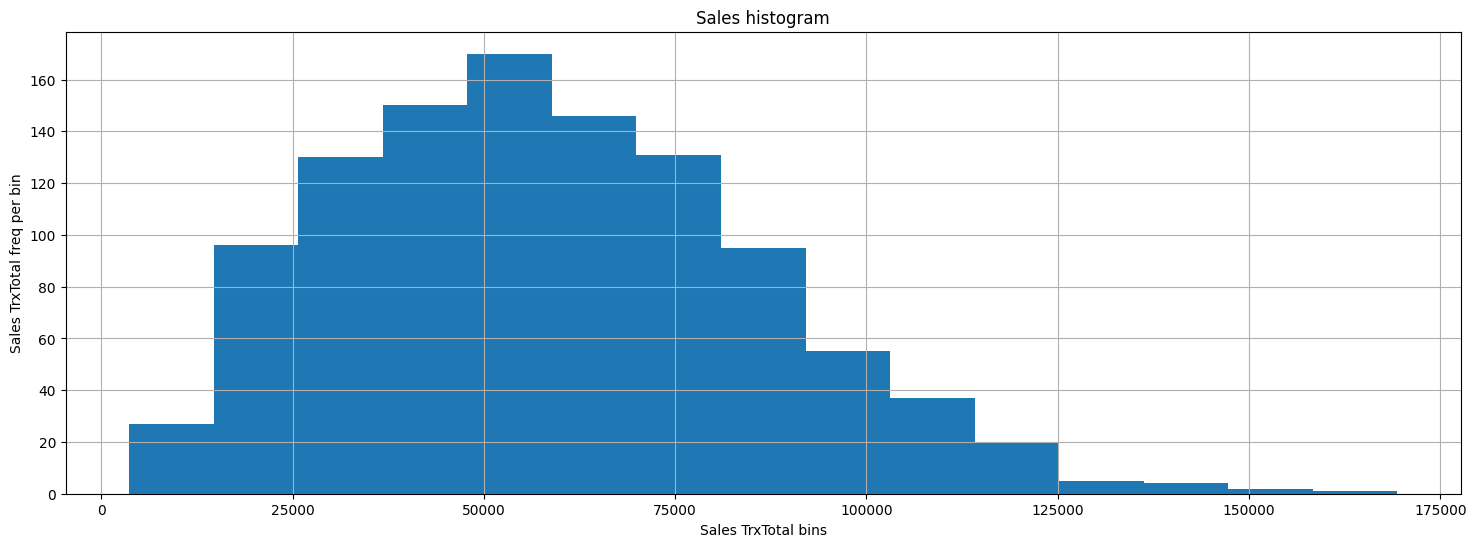

In [111]:
plt.figure(figsize = (18,6))

count, bins = np.histogram(df['TrxTotal'], bins=15)
print("{} {}".format(count, bins))
#plt.stairs(count, bins)
#plt.hist(bins[:-1], bins, weights=count)

plt.hist(df['TrxTotal'], bins=15)
plt.title('Sales histogram')
plt.xlabel('Sales TrxTotal bins')
plt.ylabel('Sales TrxTotal freq per bin')
plt.grid(axis='both')
#plt.show()

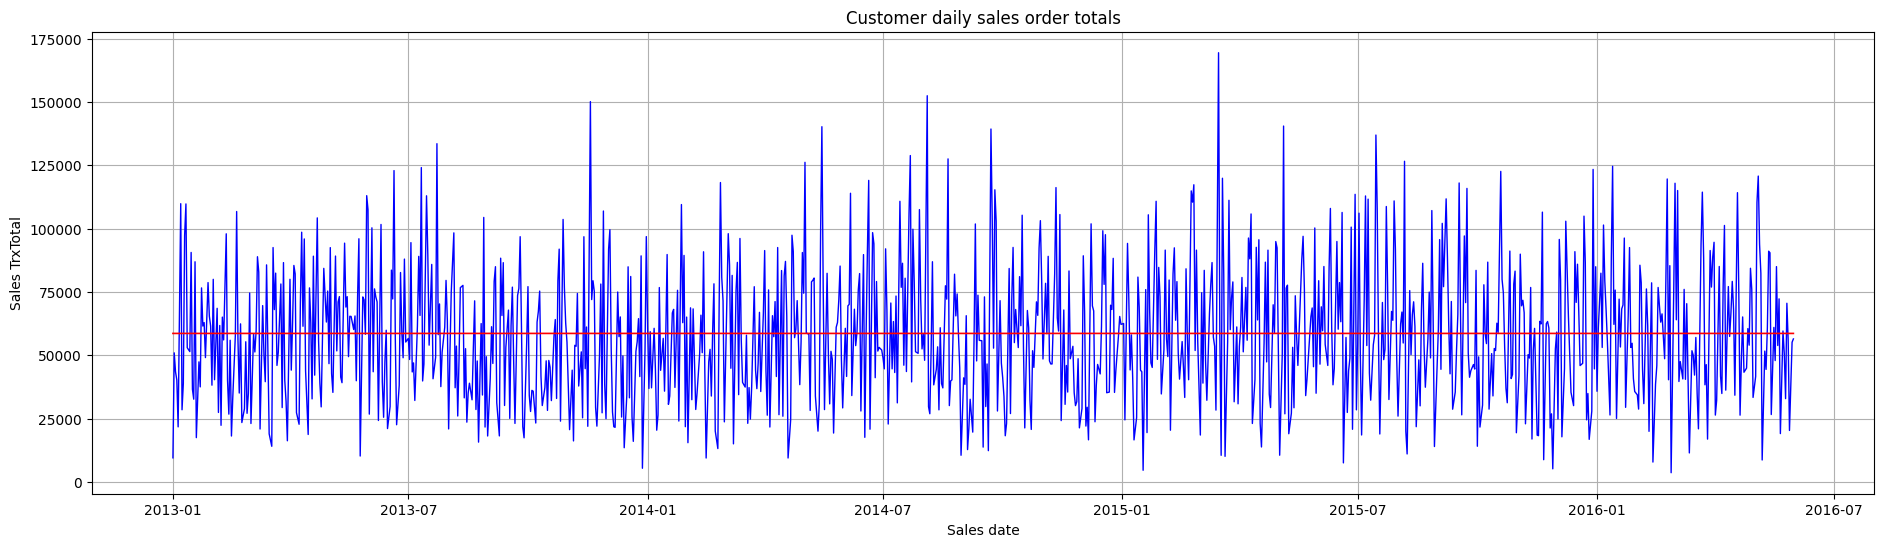

In [125]:
plt.close('all')

plt.figure(figsize = (23,6))

plt.plot(df['TransactionDate'], df['TrxTotal'], linestyle='-', color='blue', linewidth=1)
plt.title('Customer daily sales order totals')
plt.xlabel('Sales date')
plt.ylabel('Sales TrxTotal')
plt.grid(axis='both')

plt.plot(df['TransactionDate'], np.full(len(df), df['TrxTotal'].mean()), linestyle='-', 
         color='red', linewidth=1.2)
#plt.show()

In [272]:
print(df.loc[0:312,'TransactionDate'])

0     2013-01-01
1     2013-01-02
2     2013-01-03
3     2013-01-04
4     2013-01-05
         ...    
308   2013-12-26
309   2013-12-27
310   2013-12-28
311   2013-12-30
312   2013-12-31
Name: TransactionDate, Length: 313, dtype: datetime64[ns]


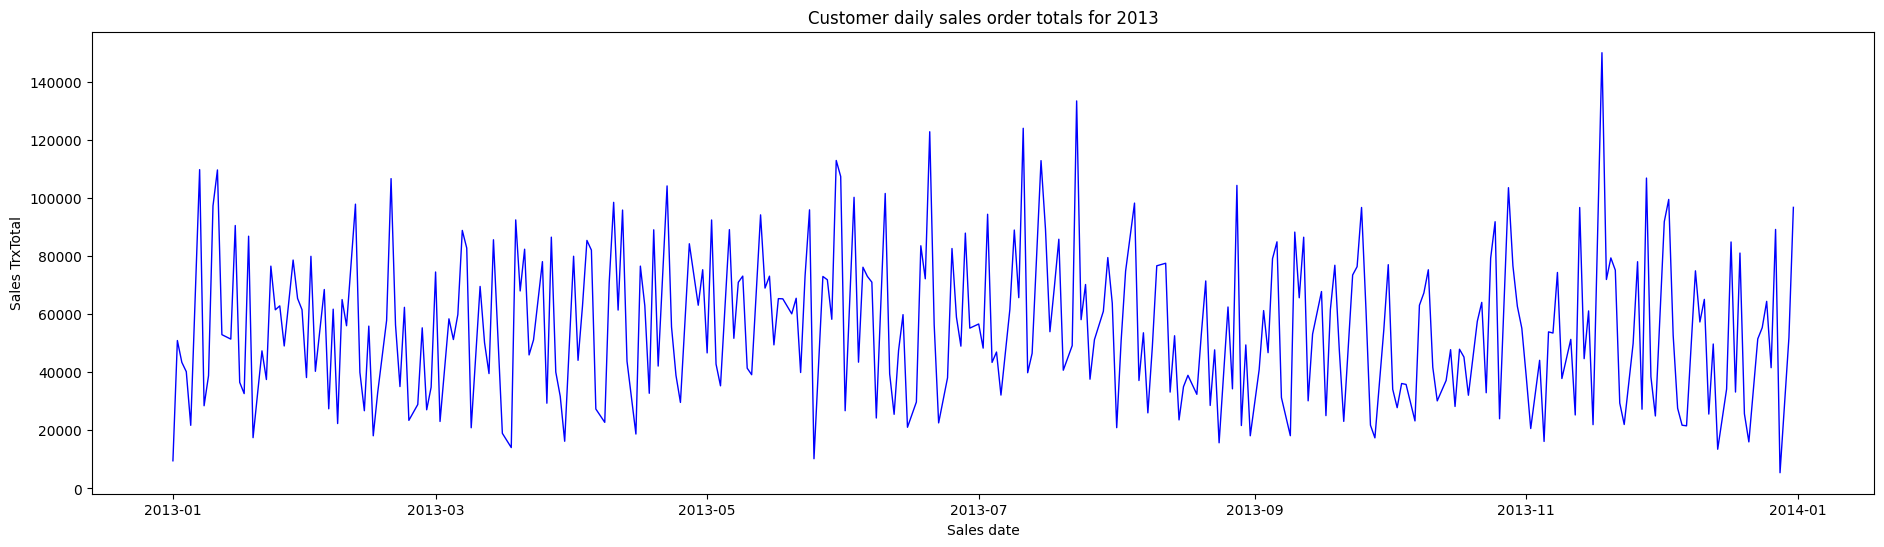

In [126]:
plt.close('all')

plt.figure(figsize = (23,6))
plt.title('Customer daily sales order totals for 2013')
plt.xlabel('Sales date')
plt.ylabel('Sales TrxTotal')
plt.plot(df.loc[0:312, 'TransactionDate'], df.loc[0:312, 'TrxTotal'], linestyle='-', color='blue', linewidth=1)
#plt.show()

In [128]:
print(df.loc[313:625,'TransactionDate'])

313   2014-01-01
314   2014-01-02
315   2014-01-03
316   2014-01-04
317   2014-01-06
         ...    
621   2014-12-26
622   2014-12-27
623   2014-12-29
624   2014-12-30
625   2014-12-31
Name: TransactionDate, Length: 313, dtype: datetime64[ns]


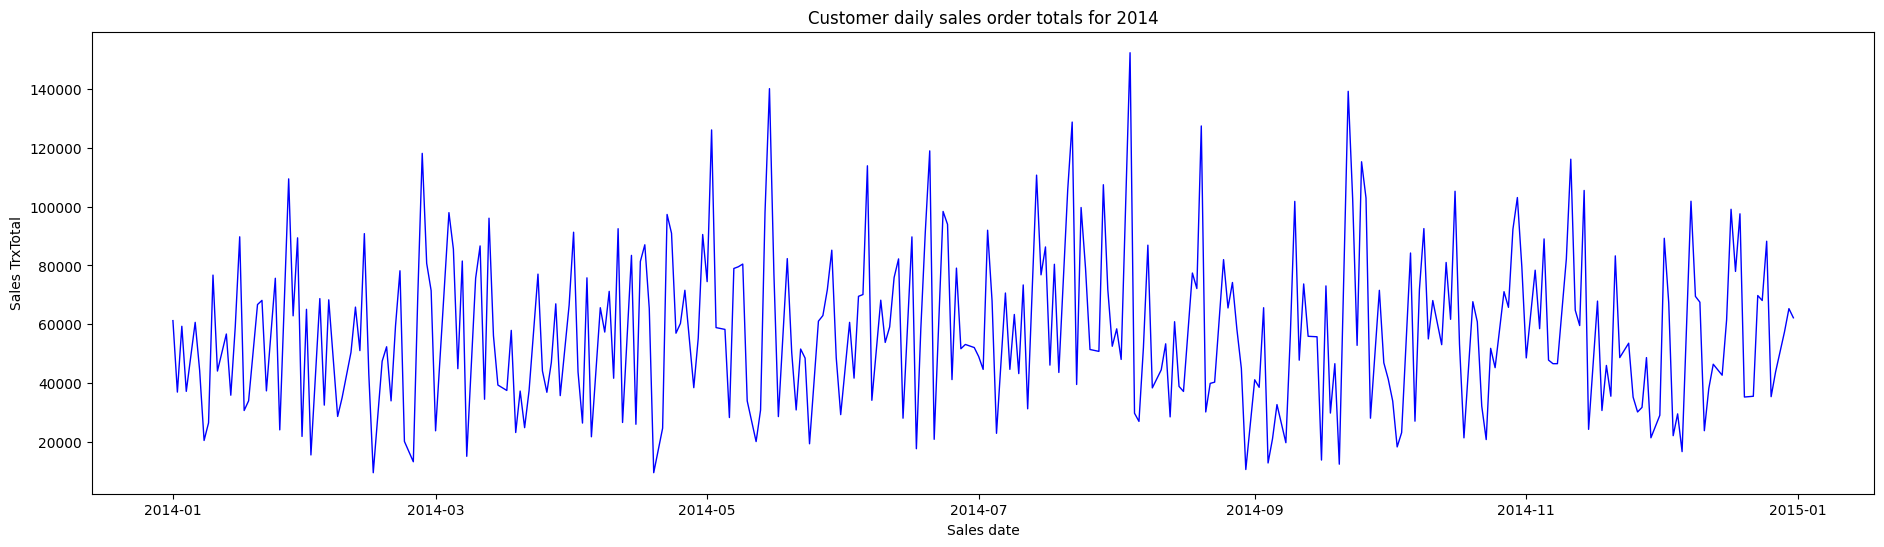

In [129]:
plt.close('all')

plt.figure(figsize = (23,6))
plt.title('Customer daily sales order totals for 2014')
plt.xlabel('Sales date')
plt.ylabel('Sales TrxTotal')
plt.plot(df.loc[313:625, 'TransactionDate'], df.loc[313:625, 'TrxTotal'], linestyle='-', color='blue', linewidth=1)
#plt.show()

In [273]:
print(df.loc[626:,'TransactionDate'])

626    2015-01-01
627    2015-01-02
628    2015-01-03
629    2015-01-05
630    2015-01-06
          ...    
1064   2016-05-26
1065   2016-05-27
1066   2016-05-28
1067   2016-05-30
1068   2016-05-31
Name: TransactionDate, Length: 443, dtype: datetime64[ns]


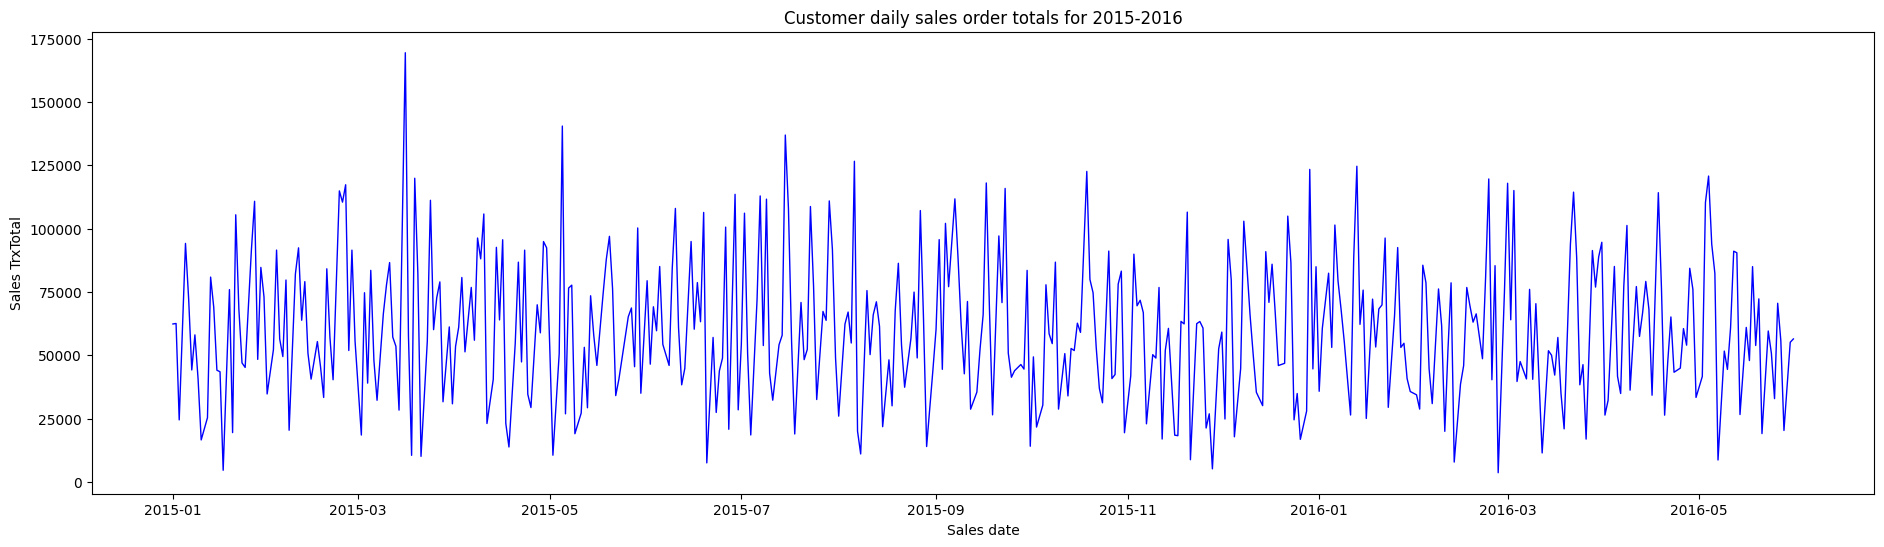

In [131]:
plt.close('all')

plt.figure(figsize = (23,6))
plt.title('Customer daily sales order totals for 2015-2016')
plt.xlabel('Sales date')
plt.ylabel('Sales TrxTotal')
plt.plot(df.loc[626:, 'TransactionDate'], df.loc[626:, 'TrxTotal'], linestyle='-', color='blue', linewidth=1)
#plt.show()

In [139]:
dfts = df.loc[:, ['TransactionDate', 'TrxTotal']]

In [140]:
print(dfts.dtypes)

TransactionDate    datetime64[ns]
TrxTotal                  float64
dtype: object


In [141]:
dfts.set_index('TransactionDate', inplace=True)

In [142]:
print(dfts)

                 TrxTotal
TransactionDate          
2013-01-01        9513.49
2013-01-02       50940.86
2013-01-03       43437.29
2013-01-04       40219.65
2013-01-05       21730.00
...                   ...
2016-05-26       70512.35
2016-05-27       55819.67
2016-05-28       20310.38
2016-05-30       55119.07
2016-05-31       56435.84

[1069 rows x 1 columns]


In [274]:
dftsintp = dfts.asfreq('D', fill_value=df['TrxTotal'].mean())
dftsintp = dftsintp.sort_index()

print(dftsintp)

                     TrxTotal
TransactionDate              
2013-01-01        9513.490000
2013-01-02       50940.860000
2013-01-03       43437.290000
2013-01-04       40219.650000
2013-01-05       21730.000000
...                       ...
2016-05-27       55819.670000
2016-05-28       20310.380000
2016-05-29       58610.161422
2016-05-30       55119.070000
2016-05-31       56435.840000

[1247 rows x 1 columns]


In [275]:
print(dftsintp.loc['2013-01-01': '2013-12-31'])

                     TrxTotal
TransactionDate              
2013-01-01        9513.490000
2013-01-02       50940.860000
2013-01-03       43437.290000
2013-01-04       40219.650000
2013-01-05       21730.000000
...                       ...
2013-12-27       89213.790000
2013-12-28        5398.100000
2013-12-29       58610.161422
2013-12-30       51975.170000
2013-12-31       96818.680000

[365 rows x 1 columns]


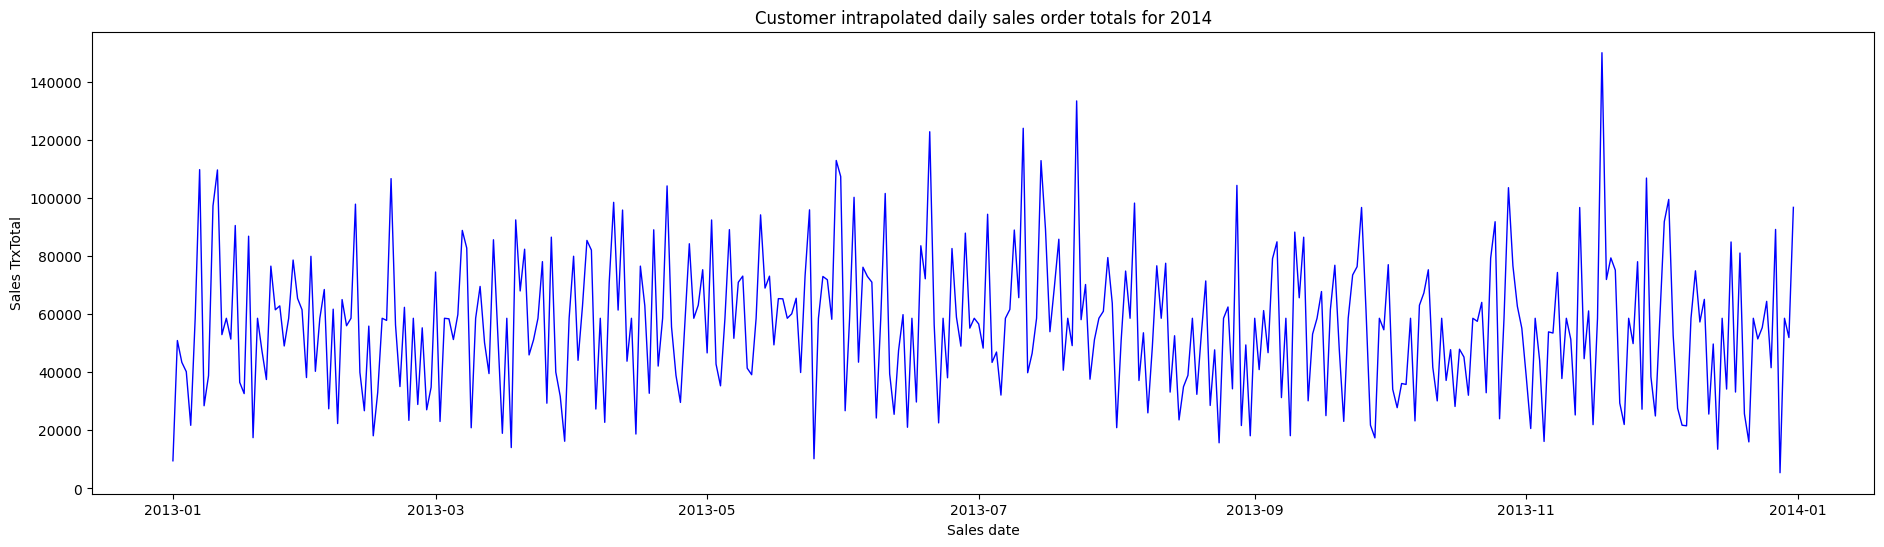

In [276]:
plt.close('all')

plt.figure(figsize = (23,6))
plt.title('Customer intrapolated daily sales order totals for 2013')
plt.xlabel('Sales date')
plt.ylabel('Sales TrxTotal')
plt.plot(dftsintp.loc['2013-01-01': '2013-12-31'], linestyle='-', color='blue', linewidth=1)
#plt.show()

In [278]:
print(dftsintp.loc['2014-01-01': '2014-12-31'])

                     TrxTotal
TransactionDate              
2014-01-01       61211.570000
2014-01-02       36879.070000
2014-01-03       59288.430000
2014-01-04       37133.730000
2014-01-05       58610.161422
...                       ...
2014-12-27       43727.830000
2014-12-28       58610.161422
2014-12-29       57363.100000
2014-12-30       65300.060000
2014-12-31       62178.660000

[365 rows x 1 columns]


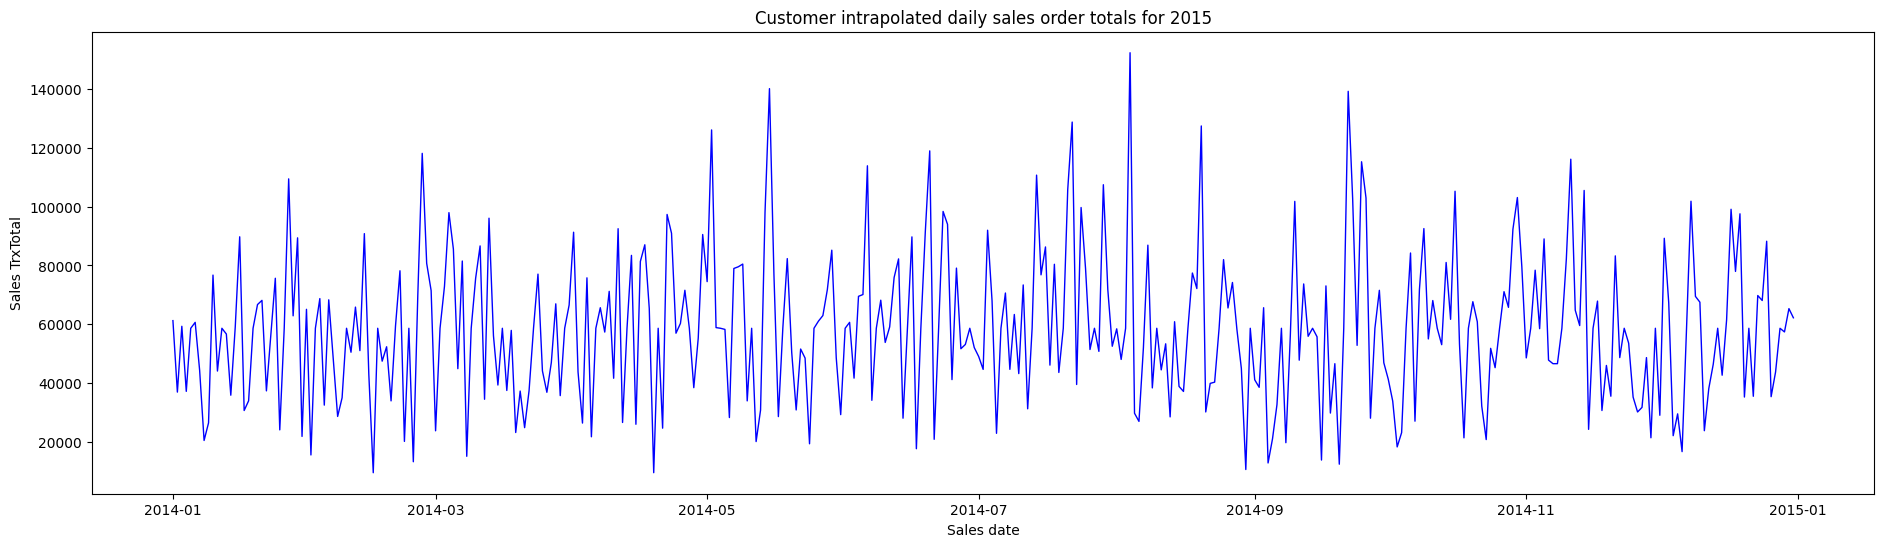

In [279]:
plt.close('all')

plt.figure(figsize = (23,6))
plt.title('Customer intrapolated daily sales order totals for 2014')
plt.xlabel('Sales date')
plt.ylabel('Sales TrxTotal')
plt.plot(dftsintp.loc['2014-01-01': '2014-12-31'], linestyle='-', color='blue', linewidth=1)
#plt.show()

In [281]:
print(dftsintp.loc['2015-01-01': '2015-12-31'])

                      TrxTotal
TransactionDate               
2015-01-01        62334.320000
2015-01-02        62534.660000
2015-01-03        24483.160000
2015-01-04        58610.161422
2015-01-05        94131.260000
...                        ...
2015-12-27        58610.161422
2015-12-28        27959.890000
2015-12-29       123339.060000
2015-12-30        44604.190000
2015-12-31        84928.320000

[365 rows x 1 columns]


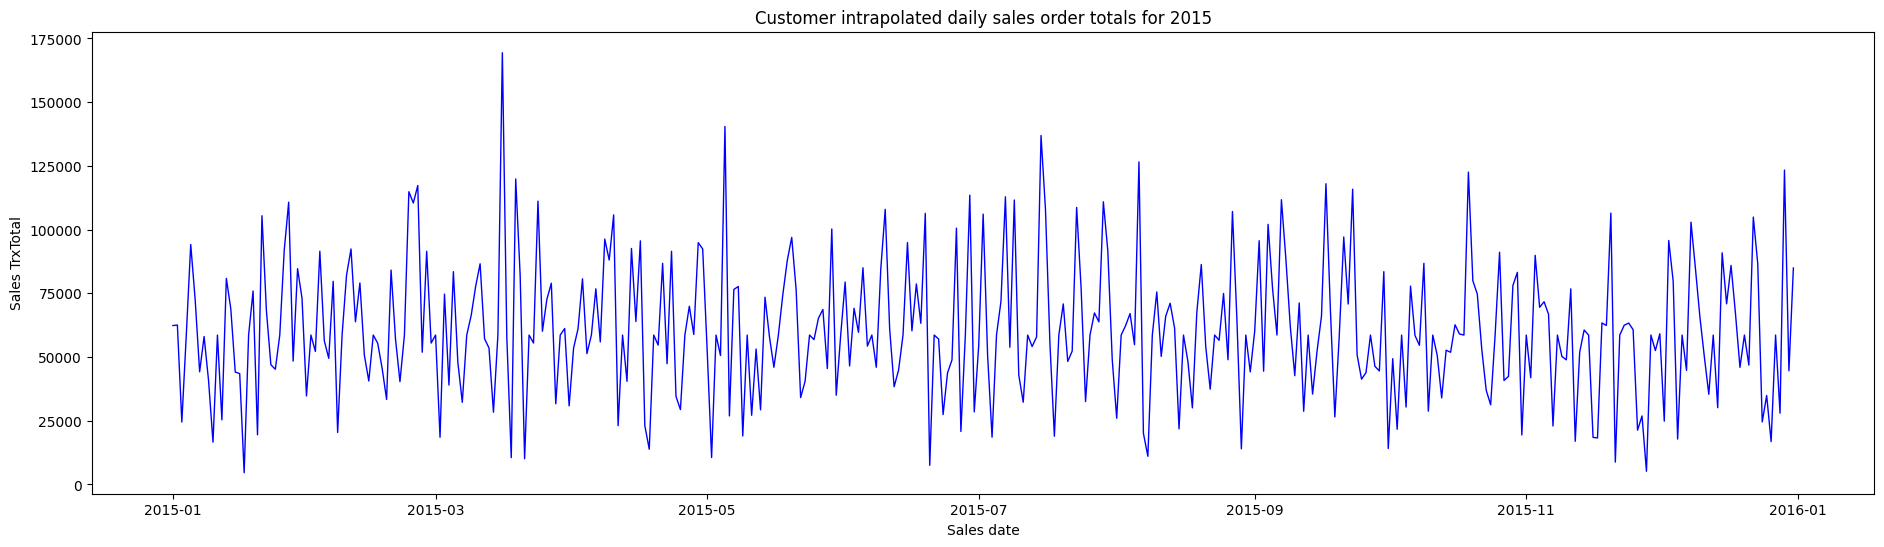

In [282]:
plt.close('all')

plt.figure(figsize = (23,6))
plt.title('Customer intrapolated daily sales order totals for 2015')
plt.xlabel('Sales date')
plt.ylabel('Sales TrxTotal')
plt.plot(dftsintp.loc['2015-01-01': '2015-12-31'], linestyle='-', color='blue', linewidth=1)
#plt.show()

In [283]:
print(dftsintp.loc['2016-01-01': '2016-12-31'])

                     TrxTotal
TransactionDate              
2016-01-01       35779.030000
2016-01-02       60604.550000
2016-01-03       58610.161422
2016-01-04       82377.090000
2016-01-05       53079.260000
...                       ...
2016-05-27       55819.670000
2016-05-28       20310.380000
2016-05-29       58610.161422
2016-05-30       55119.070000
2016-05-31       56435.840000

[152 rows x 1 columns]


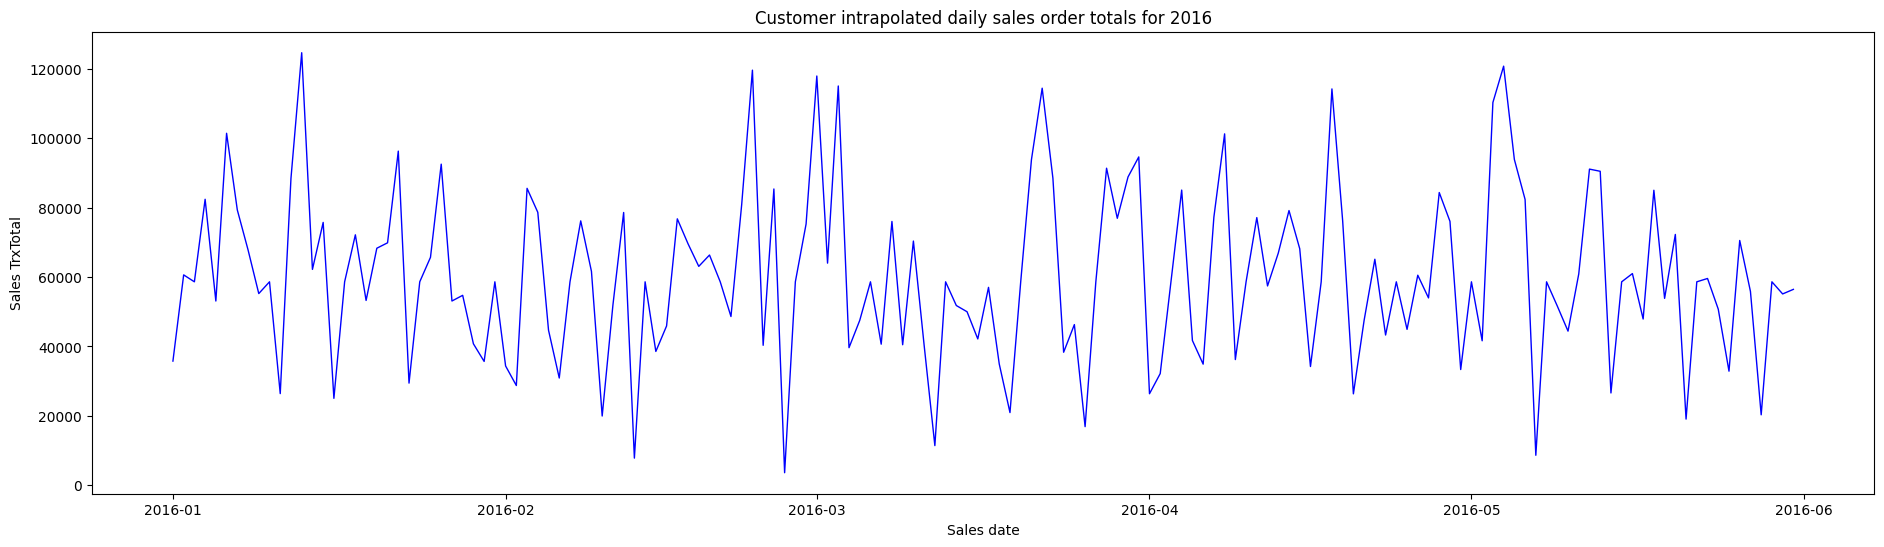

In [285]:
plt.close('all')

plt.figure(figsize = (23,6))
plt.title('Customer intrapolated daily sales order totals for 2016')
plt.xlabel('Sales date')
plt.ylabel('Sales TrxTotal')
plt.plot(dftsintp.loc['2016-01-01': '2016-05-31'], linestyle='-', color='blue', linewidth=1)
#plt.show()

In [286]:
dftsintp_train = dftsintp.loc['2016-01-01': '2016-04-30']
dftsintp_test = dftsintp.loc['2016-05-01': '2016-05-31']

print(dftsintp_train)
print(dftsintp_test)

                     TrxTotal
TransactionDate              
2016-01-01       35779.030000
2016-01-02       60604.550000
2016-01-03       58610.161422
2016-01-04       82377.090000
2016-01-05       53079.260000
...                       ...
2016-04-26       60510.230000
2016-04-27       53970.760000
2016-04-28       84319.060000
2016-04-29       76014.170000
2016-04-30       33350.430000

[121 rows x 1 columns]
                      TrxTotal
TransactionDate               
2016-05-01        58610.161422
2016-05-02        41628.620000
2016-05-03       110263.570000
2016-05-04       120710.270000
2016-05-05        93841.160000
2016-05-06        82323.970000
2016-05-07         8657.660000
2016-05-08        58610.161422
2016-05-09        51638.030000
2016-05-10        44406.880000
2016-05-11        60873.010000
2016-05-12        91064.400000
2016-05-13        90435.870000
2016-05-14        26602.880000
2016-05-15        58610.161422
2016-05-16        60979.100000
2016-05-17        47898.3800

In [151]:
#data = {'Name': ['Alice', 'Bob', 'Charlie', 'David'],
#        'Age': [25, 30, 35, 40],
#        'City': ['NY', 'LA', 'Chicago', 'Houston']}
#dataf = pd.DataFrame(data, index=['a', 'b', 'c', 'd'])

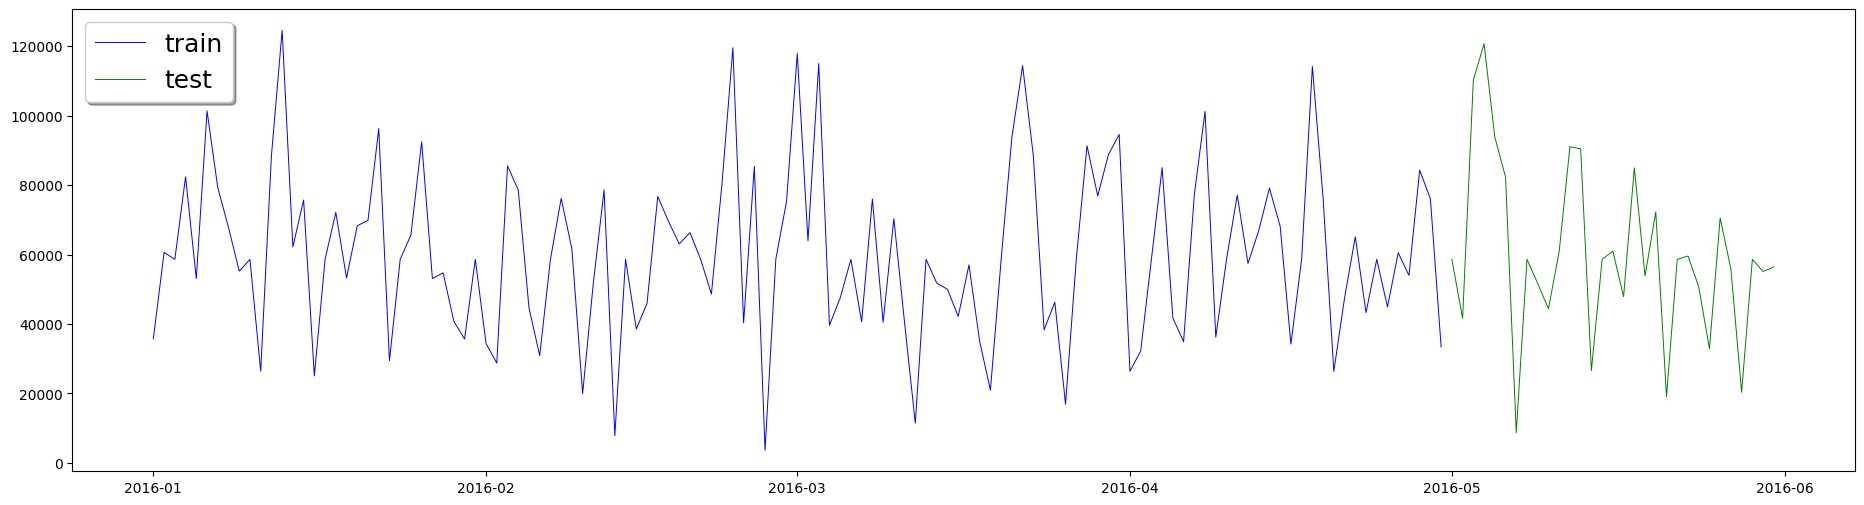

In [289]:
plt.close('all')

plt.figure(figsize = (23,6))
#plt.title('Customer daily sales order totals for 2015-2016')
#plt.xlabel('Sales date')
#plt.ylabel('Sales TrxTotal')
plt.plot(dftsintp_train, label='train', color='blue', linewidth=0.7)
plt.plot(dftsintp_test, label='test', color='green', linewidth=0.7)
plt.legend(loc='upper left', fontsize=18, frameon=True, shadow=True)
#plt.show()

In [290]:
# Initial timeseries forecaster using RandomForestRegressor

forecaster = ForecasterRecursive(regressor=RandomForestRegressor(random_state=123, verbose=0), lags=30)  #180 #120
forecaster.fit(y=dftsintp_train['TrxTotal'])
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30] 
Window features: None 
Window size: 30 
Series name: TrxTotal 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2016-01-01 00:00:00'), Timestamp('2016-04-30 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-10-24 16:34:10 
Last fit date: 2025-10-24 16:34:10 
Skforecast version: 0.18.0 
Python version: 3.9.13 
Forecaster id: None

In [297]:
predictions = forecaster.predict(steps = 31)  #249 #60
predictions.head(10)

2016-05-01    55461.640639
2016-05-02    64593.464585
2016-05-03    67211.593885
2016-05-04    43528.154628
2016-05-05    54879.023184
2016-05-06    62776.907113
2016-05-07    53152.434300
2016-05-08    56770.643353
2016-05-09    55081.570042
2016-05-10    58131.101528
Freq: D, Name: pred, dtype: float64

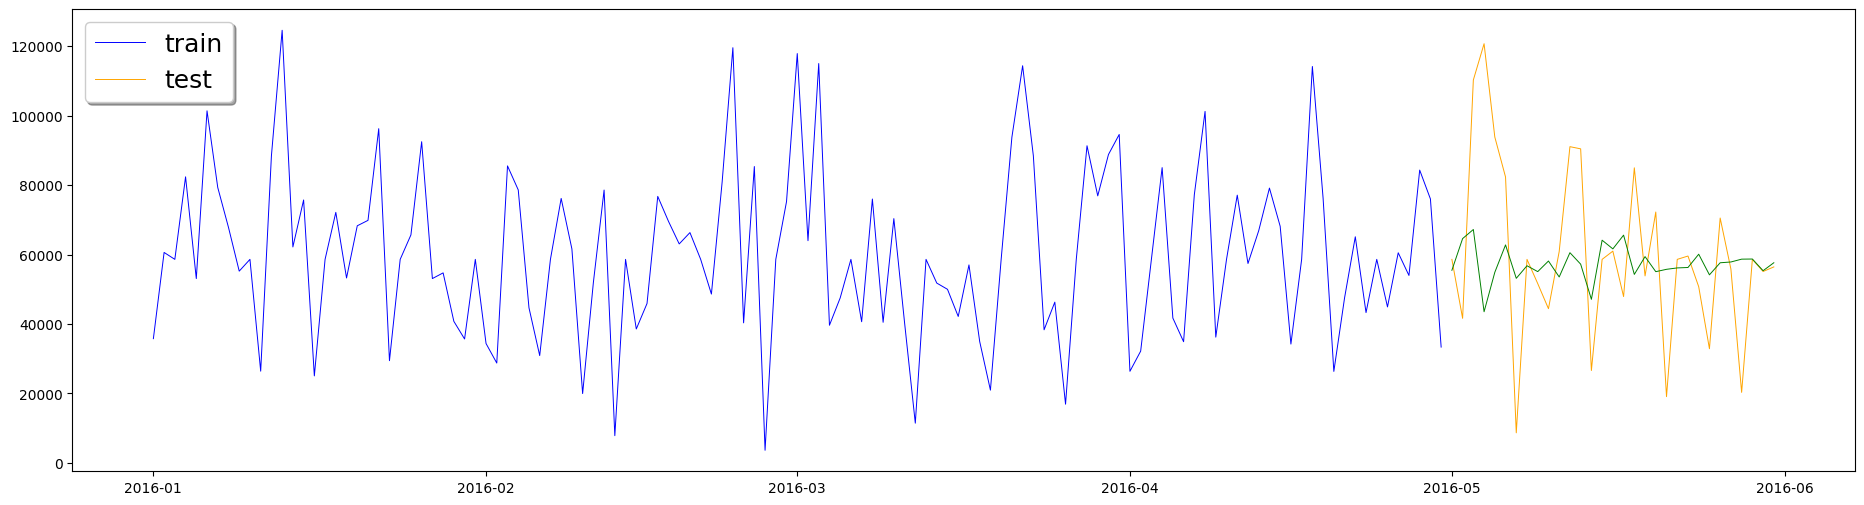

In [298]:
plt.close('all')

plt.figure(figsize = (23,6))
#plt.title('Customer daily sales order totals for 2015-2016')
#plt.xlabel('Sales date')
#plt.ylabel('Sales TrxTotal')
plt.plot(dftsintp_train, label='train', color='blue', linewidth=0.7)
plt.plot(dftsintp_test, label='test', color='orange', linewidth=0.7)
plt.plot(predictions, color='green', linewidth=0.7)
plt.legend(loc='upper left', fontsize=18, frameon=True, shadow=True)
#plt.show()

In [300]:
err = mean_squared_error(y_true = dftsintp_test.loc['2016-05-01': '2016-05-31', 'TrxTotal'], y_pred = predictions)
print(err)

648304709.4056227


In [301]:
results = grid_search_forecaster(forecaster = forecaster, y = dftsintp_train['TrxTotal'], 
                                 cv = TimeSeriesFold(steps=31, initial_train_size=int(len(dftsintp_train) * 0.5),
                                                    refit=False, fixed_train_size=False),
                                lags_grid=[10, 20], param_grid={'n_estimators': [100, 250], 'max_depth': [3, 8]},
                                metric='mean_squared_error', return_best=True, n_jobs='auto', verbose=False)

lags grid: 100%|██████████| 2/2 [00:20<00:00, 10.33s/it]  

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20] 
  Parameters: {'max_depth': 8, 'n_estimators': 100}
  Backtesting metric: 640882542.1122055


In [443]:
# Revised timeseries forecaster using RandomForestRegressor

forecaster = ForecasterRecursive(regressor=RandomForestRegressor(random_state=123, verbose=0, 
                                                                 max_depth=5, n_estimators=5), lags=30)
forecaster.fit(y=dftsintp_train['TrxTotal'])
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30] 
Window features: None 
Window size: 30 
Series name: TrxTotal 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2016-01-01 00:00:00'), Timestamp('2016-04-30 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    5, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 5,
    'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-11-04 22:05:02 
Last fit date: 2025-11-04 22:05:02 
Skforecast version: 0.18.0 
Python version: 3.9.13 
Forecaster id: None

In [465]:
predictions = forecaster.predict(steps = 31)
predictions.head(10)

#test = predictions.to_json()
#test = predictions.index.to_list()
#print(test)

2016-05-01    67280.320243
2016-05-02    71215.484429
2016-05-03    56641.535292
2016-05-04    60101.434809
2016-05-05    68071.269942
2016-05-06    58583.324559
2016-05-07    51929.955373
2016-05-08    60365.464077
2016-05-09    58214.647662
2016-05-10    53213.019304
Freq: D, Name: pred, dtype: float64

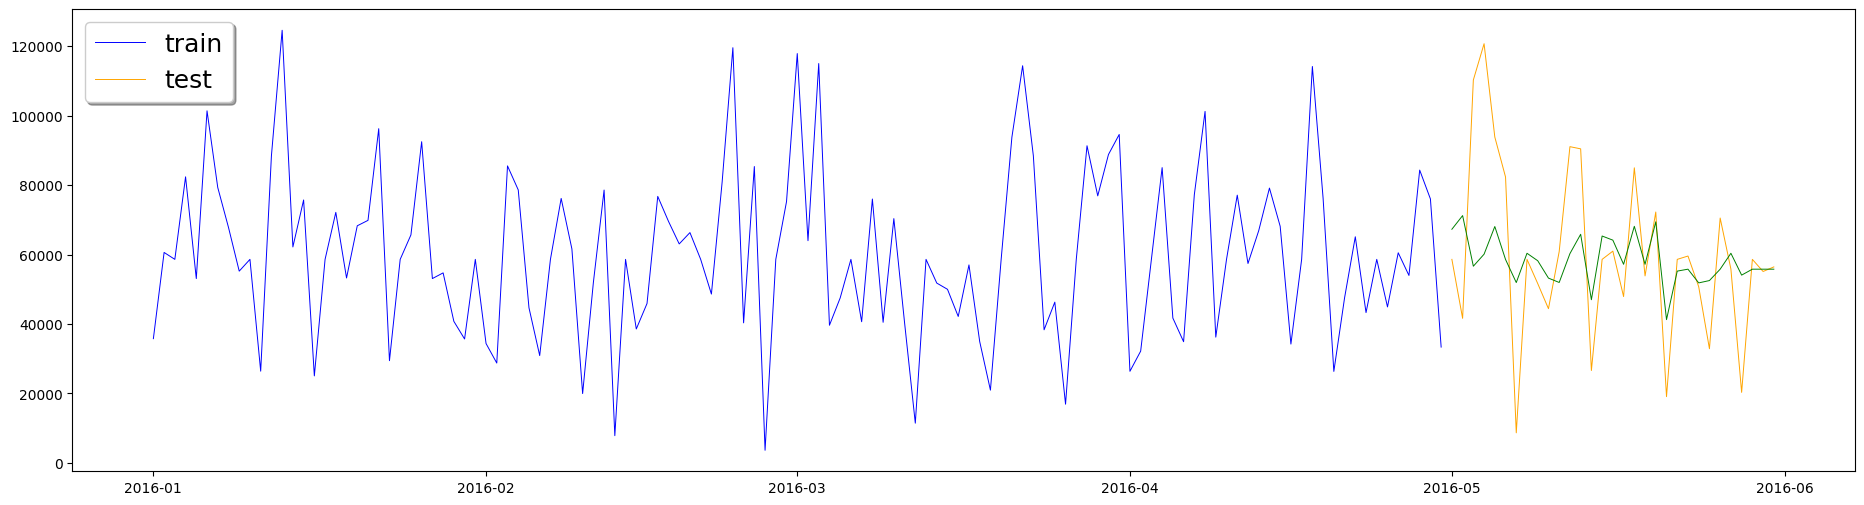

In [445]:
plt.close('all')

plt.figure(figsize = (23,6))
#plt.title('Customer daily sales order totals for 2015-2016')
#plt.xlabel('Sales date')
#plt.ylabel('Sales TrxTotal')
plt.plot(dftsintp_train, label='train', color='blue', linewidth=0.7)
plt.plot(dftsintp_test, label='test', color='orange', linewidth=0.7)
plt.plot(predictions, color='green', linewidth=0.7)
plt.legend(loc='upper left', fontsize=18, frameon=True, shadow=True)
#plt.show()

In [423]:
# RandomForestRegressor estimator and max_depth parameter tuning with grid search function

results = grid_search_forecaster(forecaster = forecaster, y = dftsintp_train['TrxTotal'], 
                                 cv = TimeSeriesFold(steps=31, initial_train_size=int(len(dftsintp_train) * 0.5),
                                                    refit=False, fixed_train_size=False),
                                lags_grid=[30], param_grid={'n_estimators': [5, 7, 12, 15, 50, 100, 150, 200, 250], 
                                                          'max_depth': [5, 6, 7, 8, 9, 10]},
                                metric='mean_squared_error', return_best=True, n_jobs='auto', verbose=False)

lags grid: 100%|██████████| 1/1 [00:10<00:00, 10.15s/it]    

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30] 
  Parameters: {'max_depth': 5, 'n_estimators': 5}
  Backtesting metric: 554171037.9461054


In [421]:
#pd.set_option('display.max_rows', None)
results

,lags,lags_label,params,mean_squared_error,max_depth,n_estimators
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 5, 'n_estimators': 5}",5.541710e+08,5,5
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 6, 'n_estimators': 12}",5.652209e+08,6,12
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 5, 'n_estimators': 7}",5.664193e+08,5,7
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 5, 'n_estimators': 15}",5.711542e+08,5,15
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 7, 'n_estimators': 12}",5.715651e+08,7,12
5,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 8, 'n_estimators': 12}",5.731933e+08,8,12
6,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'n_estimators': 12}",5.731933e+08,10,12
7,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 9, 'n_estimators': 12}",5.731933e+08,9,12
8,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 5, 'n_estimators': 12}",5.867114e+08,5,12
9,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'n_estimators': 7}",5.881022e+08,10,7
